In [1]:
from cfa import average_rank_combination, average_score_combination, weighted_score_combination_by_ds, weighted_rank_combination_by_ds
from cfa import cfa_single_layer, performance_plot, RSC_graph, compute_cd_ds, compute_performance
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # for RSC function graph
import pandas as pd
import numpy as np
from itertools import combinations

In [3]:
# calculate performance for each column using precision@k (k = 100, 200, 300)
def precision_at_k_score(df, k):
    df = pd.concat([df, y_true], axis=1)
    precisions = {}
    # find columns without "arc"/"wrcds" in their names
    columns = [col for col in df.columns if "arc" not in col and "wrcds" not in col and col != 'Rating']
    for column in columns:
        df_sorted = df.sort_values(by=column, ascending=False).reset_index(drop=True)
        prec = df_sorted['Rating'].head(k).sum() / k
        precisions[column] = prec
    return precisions

In [4]:
# calculate performance for each column using precision@k (k = 100, 200, 300)
def precision_at_k_rank(df, k):
    df = pd.concat([df, y_true], axis=1)
    precisions = {}
    # find columns with "arc"/"wrcds" in their names
    columns = [col for col in df.columns if "arc" in col or "wrcds" in col]
    for column in columns: 
        df_sorted = df.sort_values(by=column, ascending=False).reset_index(drop=True) # in MCF, we keep score and rank same direction
        prec = df_sorted['Rating'].head(k).sum() / k
        precisions[column] = prec
    return precisions

In [5]:
# Load the dataset
df = pd.read_csv('ScoreFunctions-withRating.csv')

# map right to 0 and left to 1 for column Rating
df['Rating'] = df['Rating'].map({'Right': 0, 'Left': 1}) 
df.head(5)

,A,B,C,D,E,Rating
0,0.0,0.460124,0.428571,0.468178,0.463415,0
1,0.0,0.498609,0.571429,0.469353,0.512195,0
2,1.0,0.535394,0.628571,0.385390,0.463415,1
3,1.0,0.607883,0.828571,0.363728,0.585366,1
4,1.0,0.551005,0.600000,0.398489,0.365854,1


In [6]:
df1 = df[['A', 'B', 'C', 'D', 'E']]
df1.head(2)

,A,B,C,D,E
0,0.0,0.460124,0.428571,0.468178,0.463415
1,0.0,0.498609,0.571429,0.469353,0.512195


In [7]:
y_true = df['Rating']

In [8]:
def EAR(df: pd.DataFrame, reduction_method: str) -> pd.DataFrame:

    #------------- Expansion begin: input: five scoring systems (df, pd.DataFrame) ------------
    ASC_df = average_score_combination(df); WSCDS_df = weighted_score_combination_by_ds(df)
    ASC_df = ASC_df.add_suffix("_asc"); WSCDS_df = WSCDS_df.add_suffix("_wscds")
    SC_df = pd.concat([ASC_df, WSCDS_df], axis = 1) # 52 combination for reduction, no base models
    #------------- Expansion end: output: expanded scoring systems (SC_df, pd.DataFrame) --------

    SC_df_eval = pd.concat([df, SC_df], axis = 1) # 52 + 5 combinations for evaluation

    #------------- Reduction begin: input: expanded scoring systems (SC_df, pd.DataFrame) -------------
    ## 1. drop constant columns --> 2. remove duplicate columns --> 3. compute ds -->
    ## 4. select top five by ds --> 5. rename to A, B, C, D, E, etc.
    if SC_df.shape[0] > 1: # in case only has one row, all cols become constant
        const_cols = SC_df.columns[SC_df.nunique() <= 1] # drop constant columns
        SC_df = SC_df.drop(columns = const_cols)
    SC_df = SC_df.loc[:, ~SC_df.round(6).T.duplicated()] # remove duplicates, 6 digits for float precision

    if reduction_method == 'performance':
        red_perf = compute_performance(SC_df, y_true, perf_metric="precision@k", k = 200)
        reduce_five = red_perf.sort_values(ascending = False).head(5).index.tolist()
        new_five_ss = SC_df[reduce_five].copy() # avoid chained assignment warning
        
    elif reduction_method == 'diversity':
        _, _, ds = compute_cd_ds(SC_df)
        reduce_five = ds.sort_values(by = 'ds', ascending = False).index.to_list()[:5] # only use ds for reduction
        new_five_ss = SC_df[reduce_five].copy() # avoid chained assignment warning
        
    elif reduction_method == "hybrid":
        # get top 3 by performance 
        red_perf = compute_performance(SC_df, y_true, perf_metric="precision@k", k = 200)
        reduce_two = red_perf.sort_values(ascending = False).head(3).index.tolist()
        # get top 5 by diversity and remove any overlap with performance-selected ones
        _, _, ds = compute_cd_ds(SC_df)
        reduce_five = ds.sort_values(by = 'ds', ascending = False).index.to_list()[:5] # only use ds for reduction
        reduce_five = [x for x in reduce_five if x not in reduce_two] # remove any overlap
        # get top 3 by diversity 
        reduce_final_five = reduce_two + reduce_five[:2] # combine performance-selected and diversity-selected
        new_five_ss = SC_df[reduce_final_five].copy() # avoid chained assignment

    
    new_five_ss.columns = ['A', 'B', 'C', 'D', 'E']
    #------------- Reduction end: output: reduced five scoring systems (new_five_ss, pd.DataFrame) ------------ 

    return SC_df_eval, new_five_ss

In [9]:
# score combination: ASC + WSCDS
def score_combination(df):
    SC = {}
    for size in range(2, df.shape[1]+1): # from 2 to the num of columns
        for cols in combinations(df.columns, size): # form groups
            df_subset = df[list(cols)]
            avg_scores = df_subset.mean(axis = 1) # average scores: ASC
            _, _, ds_df = compute_cd_ds(df_subset)
            w_series = ds_df['ds']; w_sum = w_series.sum() # in case sum of weight = 0
            if w_sum == 0: # if ds = 0, that means all columns are indentical, just choose the first column
                ds_scores = df_subset.iloc[:, 0] # no need to combine
            else:
                ds_scores = df_subset.mul(w_series, axis = 1).sum(axis = 1) / w_sum
            # save results
            combo_name1 = ''.join(cols) + '_asc'; combo_name2 = ''.join(cols) + '_wscds'
            SC[combo_name1] = avg_scores; SC[combo_name2] = ds_scores
            
    SC_df = pd.DataFrame(SC, index = df.index)
    return SC_df

In [10]:
# rank combination: ARC + WRCDS
def rank_combination(df):
    RC = {}
    # rank direction: ascending, 1 = smallest, here in MCF, mix score and rank combinations, to keep same direction
    ranks_df = df.rank(axis = 0, ascending = True, method = "average") 
    for size in range(2, ranks_df.shape[1]+1):
        for cols in combinations(ranks_df.columns, size):
            df_subset_ranks = ranks_df[list(cols)]
            df_subset = df[list(cols)] # ds is computed from raw scores
            avg_scores = df_subset_ranks.mean(axis = 1) # average rank combination: ARC
            _, _, ds_df = compute_cd_ds(df_subset)
            w_series = ds_df['ds']; w_sum = w_series.sum()
            if w_sum == 0: # if ds = 0, that means all columns are indentical, just choose the first column
                ds_scores = df_subset_ranks.iloc[:, 0] # no need to combine  
            else:          
                # weight and rank direction should be consistent: ascending + raw weight; descending + inverted weight
                ds_scores = df_subset_ranks.mul(w_series, axis = 1).sum(axis = 1) / w_sum
            # save results
            combo_name1 = ''.join(cols) + '_arc'; combo_name2 = ''.join(cols) + '_wrcds'
            RC[combo_name1] = avg_scores; RC[combo_name2] = ds_scores
            
    RC_df = pd.DataFrame(RC, index = df.index)
    return RC_df

In [11]:
def EAR_full(df: pd.DataFrame) -> pd.DataFrame:

    #------------- Expansion begin: input: five scoring systems (df, pd.DataFrame) ------------
    SC_df = score_combination(df); RC_df = rank_combination(df)
    SC_RC = pd.concat([SC_df, RC_df], axis = 1) # 104 combination for reduction, no base models
    #------------- Expansion end: output: expanded scoring systems (SC_RC, pd.DataFrame) --------

    SC_RC_df = pd.concat([df, SC_df, RC_df], axis = 1) # 104 + 5 combinations for evaluation

    #------------- Reduction begin: input: expanded scoring systems (SC_RC, pd.DataFrame) -------------
    ## 1. drop constant columns --> 2. remove duplicate columns --> 3. compute ds -->
    ## 4. select top five by ds --> 5. normalize rank combinations if any -->
    ## 6. rename to A, B, C, D, E, etc.
    if SC_RC.shape[0] > 1: # in case only has one row, all cols become constant
        const_cols = SC_RC.columns[SC_RC.nunique() <= 1] # drop constant columns
        SC_RC = SC_RC.drop(columns = const_cols)
    SC_RC = SC_RC.loc[:, ~SC_RC.round(6).T.duplicated()] # remove duplicates

    _, _, ds = compute_cd_ds(SC_RC)
    reduce_five = ds.sort_values(by = 'ds', ascending = False).index.to_list()[:5] # only use ds for reduction
    new_five_ss = SC_RC[reduce_five].copy() # avoid chained assignment warning
    # check if it contains any rank combination. If so, we need to normalize to [0, 1]
    mask = new_five_ss.columns.str.contains(r"arc|wrcds", regex = True) # logic: True or False
    cols_from_RC= new_five_ss[ new_five_ss.columns[mask] ] 
    if cols_from_RC.shape[1] > 0:
        new_five_ss[ cols_from_RC.columns ] = normalization(cols_from_RC)
    # after normalization, need to rename the columns to A, B, C, E, etc.
    new_five_ss.columns = ['A', 'B', 'C', 'D', 'E']
    #------------- Reduction end: output: reduced five scoring systems (new_five_ss, pd.DataFrame) ------------ 

    return SC_RC_df, new_five_ss

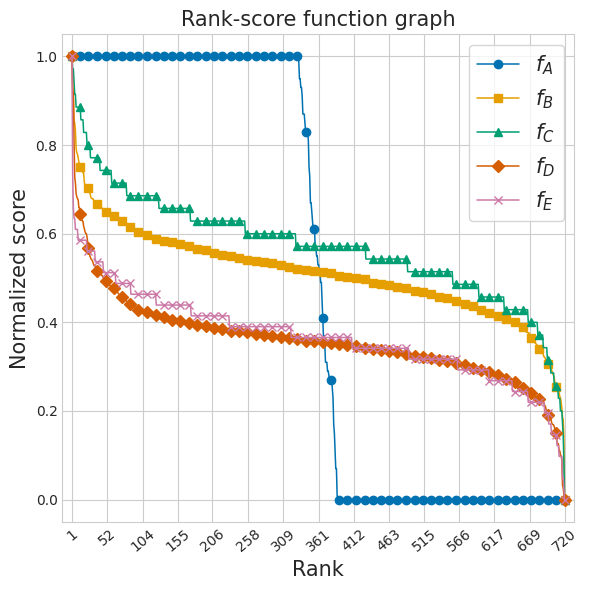

In [12]:
RSC_graph(df1)

In [16]:
def change_format_for_plot(perf_dict, include_scores=True, include_ranks=True):
    
    perf_series = pd.Series(perf_dict)
    # single-letter rows
    single = perf_series[perf_series.index.str.fullmatch(r"[A-Z]")].copy() 

    # score rows
    if include_scores:
        asc = perf_series[perf_series.index.str.endswith("_asc")].copy()
        asc.index = asc.index.str.replace(r"_asc$", "", regex=True)
        
        wscds = perf_series[perf_series.index.str.endswith("_wscds")].copy()
        wscds.index = wscds.index.str.replace(r"_wscds$", "", regex=True)

    # rank rows
    if include_ranks:
        arc = perf_series[perf_series.index.str.endswith("_arc")].copy()
        arc.index = arc.index.str.replace(r"_arc$", "", regex=True)
        
        wrcds = perf_series[perf_series.index.str.endswith("_wrcds")].copy()
        wrcds.index = wrcds.index.str.replace(r"_wrcds$", "", regex=True)


    # stack vertically: single letters first, then suffix rows
    if include_scores:
        col_asc = pd.concat([single, asc])
        col_wscds = pd.concat([single, wscds])
        df = pd.concat([col_asc, col_wscds],axis=1)
        df.columns = ["asc", "wscds"]
    if include_scores and include_ranks:
        col_asc = pd.concat([single, asc])
        col_wscds = pd.concat([single, wscds])
        col_arc = pd.concat([single, arc])
        col_wrcds = pd.concat([single, wrcds])
        df = pd.concat([col_asc, col_wscds, col_arc, col_wrcds],axis=1)
        df.columns = ["asc", "wscds", "arc", "wrcds"]
    return df

In [13]:
l1_fused, l2_new_ss = EAR(df1, reduction_method='hybrid')

In [14]:
l1_fused.head(3)

,A,B,C,D,E,AB_asc,AC_asc,AD_asc,AE_asc,BC_asc,...,BCD_wscds,BCE_wscds,BDE_wscds,CDE_wscds,ABCD_wscds,ABCE_wscds,ABDE_wscds,ACDE_wscds,BCDE_wscds,ABCDE_wscds
0,0.0,0.460124,0.428571,0.468178,0.463415,0.230062,0.214286,0.234089,0.231707,0.444348,...,0.453318,0.451191,0.463219,0.448277,0.284092,0.281481,0.277878,0.283889,0.453348,0.300261
1,0.0,0.498609,0.571429,0.469353,0.512195,0.249304,0.285714,0.234677,0.256098,0.535019,...,0.509788,0.528146,0.494083,0.528563,0.320369,0.329090,0.295648,0.327527,0.516566,0.339658
2,1.0,0.535394,0.628571,0.385390,0.463415,0.767697,0.814286,0.692695,0.731707,0.581983,...,0.501916,0.535552,0.474933,0.520220,0.691543,0.712105,0.679172,0.686655,0.510242,0.672898


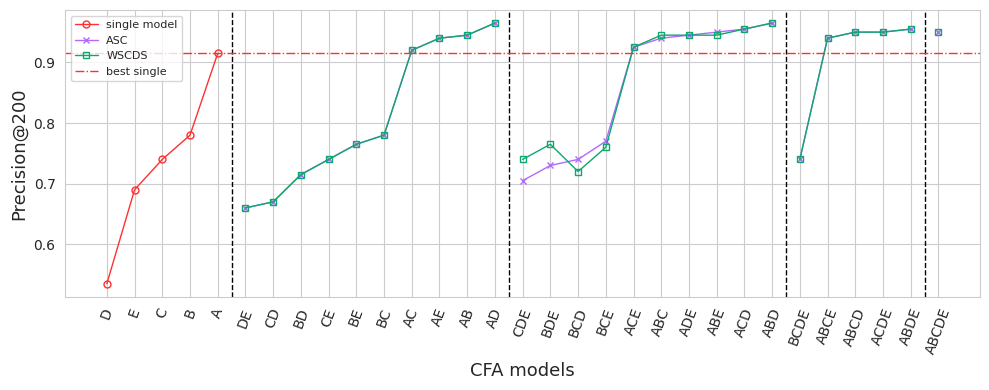

Best single: 0.9150
Best combination: 0.9650


In [17]:
# 1st layer performance: precision at k=100, 200 or 300
l1_pref_score = precision_at_k_score(l1_fused, k = 200)
l1_perf_plot_data = change_format_for_plot(l1_pref_score, include_scores=True, include_ranks=False)

p1 = performance_plot(l1_perf_plot_data, sort_col="asc", palette = ['#B368FF', "#0DA86C"],  
    markers = ['x',  's'],
    draw_cols=("asc", "wscds"), ylabel = "Precision@200"
    )

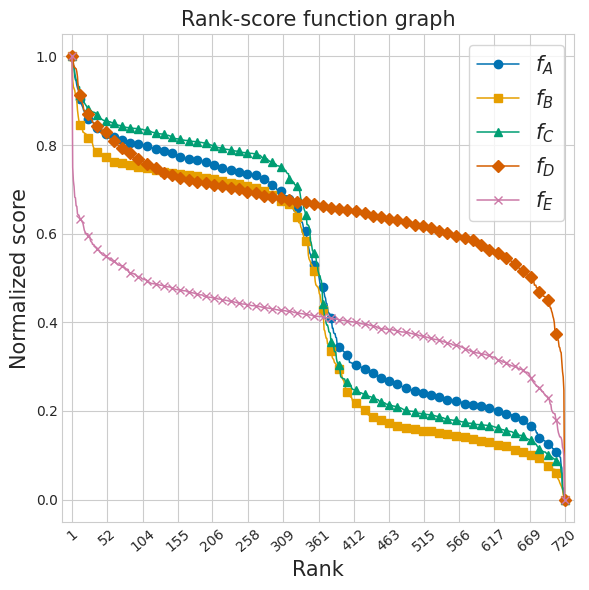

In [18]:
# 2nd layer RSC graph
RSC_graph(l2_new_ss)

In [19]:
SC_RC_df, l3_new_ss = EAR_full(l2_new_ss)

In [20]:
SC_RC_df.head(3)

,A,B,C,D,E,AB_asc,AB_wscds,AC_asc,AC_wscds,AD_asc,...,ABCE_arc,ABCE_wrcds,ABDE_arc,ABDE_wrcds,ACDE_arc,ACDE_wrcds,BCDE_arc,BCDE_wrcds,ABCDE_arc,ABCDE_wrcds
0,0.309434,0.234089,0.266965,0.448375,0.461769,0.271761,0.271761,0.288200,0.288200,0.378904,...,320.625,345.764529,317.375,318.443850,309.75,314.198109,318.375,318.998510,308.1,313.539299
1,0.322654,0.234677,0.278056,0.520391,0.505402,0.278665,0.278665,0.300355,0.300355,0.421523,...,366.500,409.829085,440.250,461.567987,437.25,461.070932,440.250,460.602058,410.6,446.157574
2,0.640262,0.692695,0.688458,0.506981,0.499404,0.666478,0.666478,0.664360,0.664360,0.573621,...,582.875,579.180163,575.000,571.722023,562.00,560.169803,575.250,571.396186,574.4,569.818907


In [21]:
l2_prec_score = precision_at_k_score(SC_RC_df, k = 200)
l2_prec_rank = precision_at_k_rank(SC_RC_df, k = 200)

# combine them together
l2_prec_score.update(l2_prec_rank) # combine score and rank performance into one dictionary

l2_perf_df = change_format_for_plot(l2_prec_score)
l2_perf_df.head(3)

,asc,wscds,arc,wrcds
A,0.965,0.965,0.965,0.965
B,0.965,0.965,0.965,0.965
C,0.965,0.965,0.965,0.965


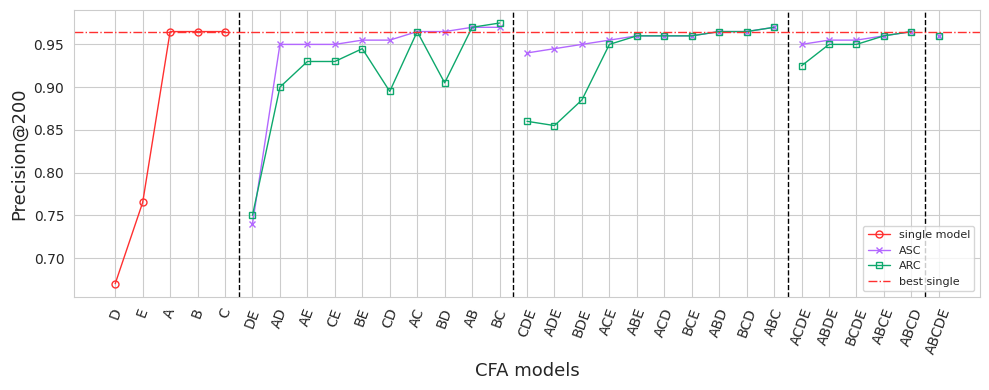

Best single: 0.9650
Best combination: 0.9750


In [22]:
# 2nd layer performance plot, precision at k=200: asc + arc
_ = performance_plot(l2_perf_df, sort_col="asc", palette = ['#B368FF', "#0DA86C"],  
    markers = ['x',  's'],
    draw_cols=("asc", "arc"),  # columns to draw lines for
    ylabel = "Precision@200"
    )

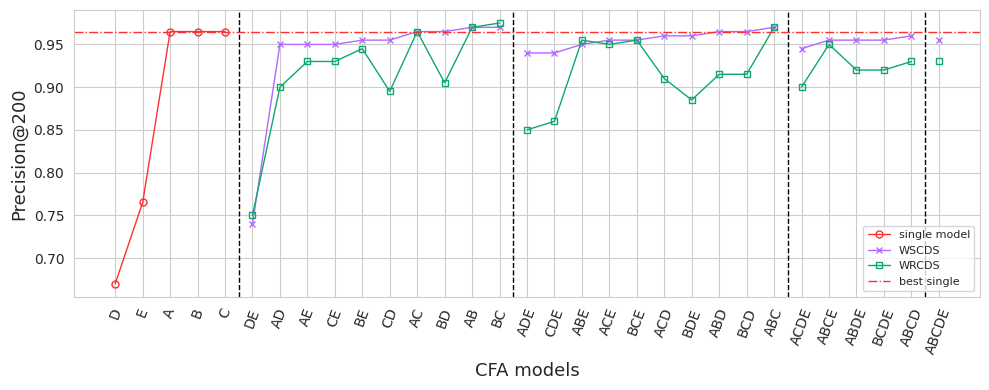

Best single: 0.9650
Best combination: 0.9750


In [23]:
# 2nd layer performance plot, precision at k=200: wscds + wrcds
_ = performance_plot(l2_perf_df, sort_col="wscds", palette = ['#B368FF', "#0DA86C"],  
    markers = ['x',  's'],
    draw_cols=("wscds", "wrcds"),  # columns to draw lines for
    ylabel = "Precision@200"
    )

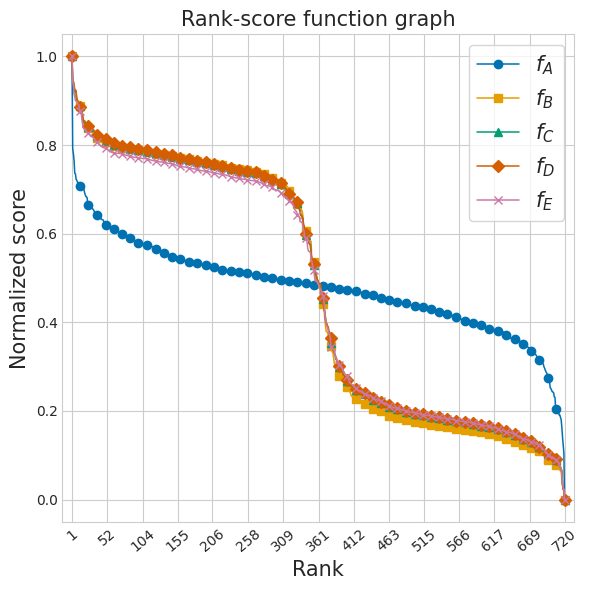

In [24]:
RSC_graph(l3_new_ss)

In [25]:
SC_RC_df_3, l4_new_ss = EAR_full(l3_new_ss)

In [26]:
l3_prec_score = precision_at_k_score(SC_RC_df_3, k = 200)
l3_prec_rank = precision_at_k_rank(SC_RC_df_3, k = 200)

# combine them together
l3_prec_score.update(l3_prec_rank) # combine score and rank performance into one dictionary
l3_perf_df = change_format_for_plot(l3_prec_score)
l3_perf_df.head(3)

,asc,wscds,arc,wrcds
A,0.74,0.74,0.74,0.74
B,0.97,0.97,0.97,0.97
C,0.97,0.97,0.97,0.97


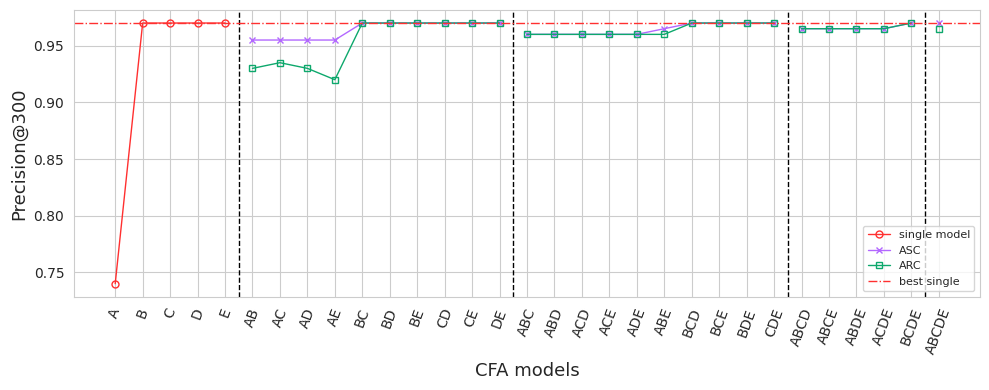

Best single: 0.9700
Best combination: 0.9700


In [234]:
# 3nd layer performance plot, precision at k=200: asc + arc
_ = performance_plot(l3_perf_df, sort_col="asc", palette = ['#B368FF', "#0DA86C"],  
    markers = ['x',  's'],
    draw_cols=("asc", "arc"),  # columns to draw lines for
    ylabel = "Precision@300"
    )

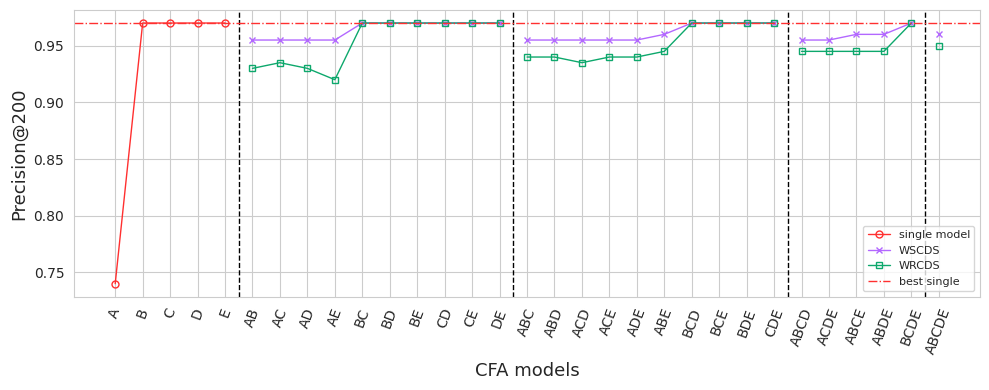

Best single: 0.9700
Best combination: 0.9700


In [27]:
# 3rd layer performance plot, precision at k=200: wscds + wrcds
_ = performance_plot(l3_perf_df, sort_col="wscds", palette = ['#B368FF', "#0DA86C"],  
    markers = ['x',  's'],
    draw_cols=("wscds", "wrcds"),  # columns to draw lines for
    ylabel = "Precision@200"
    )

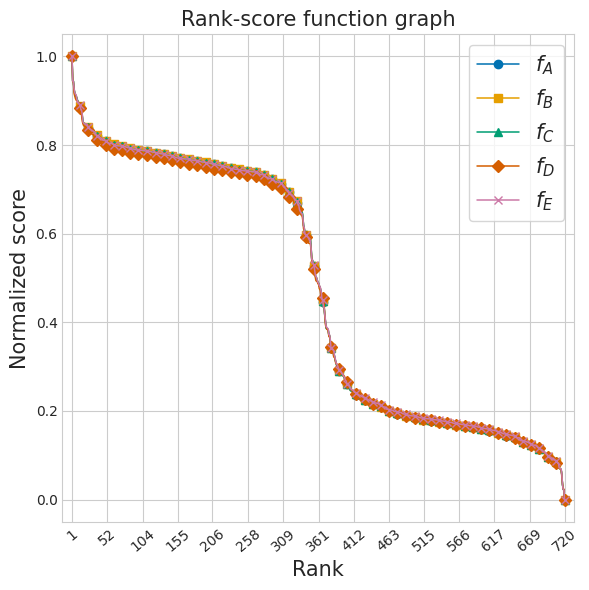

In [28]:
RSC_graph(l4_new_ss)